In [ ]:
import pandas as pd

from lib.h_ensemble import build_ensemble_csv
from lib.plots import plot_uncertainty_distributions, plot_combined_uncertainty_analysis
from lib.utils import compute_uncertainties
import numpy as np
# load data 
""" MAIN SETTINGS AND DATA LOADING"""

dataset = 'adni'
analysis_name = 'mci_ad_conversion'
outcome_name = 'label_bl_36m'
build_ensemble_csv(analysis_name, outcome_name, index_col=['subject_id','month'])


all_patients = pd.read_csv(f'../data/{dataset}/adni_baseline_only_36m.csv')



# load all predictions for the full training set (including active patients at bl)
patients_stats = pd.read_csv(f'../results/classification/{analysis_name}/{outcome_name}/aggregated/patient_mean_probs_{outcome_name}_{analysis_name}_model.csv')
patients_stats.set_index(['subject_id', 'month'], inplace=True)



# 1. Extract the inner list from each row using .str[0]
import ast

# 1. Convert the string representation "[0.8, 0.83...]" into a real Python list
real_lists = patients_stats['all_probs'].apply(ast.literal_eval)

# 2. Now expand those lists into columns
probs_raw_df = pd.DataFrame(real_lists.tolist(), index=patients_stats.index)


all_patients.set_index(['subject_id', 'month'], inplace=True)

Directory ../results/classification/mci_ad_conversion/label_bl_36m not found. Please check the path.


## Uncertainty Decomposition

Baseline entropy: 0.9950485853501994


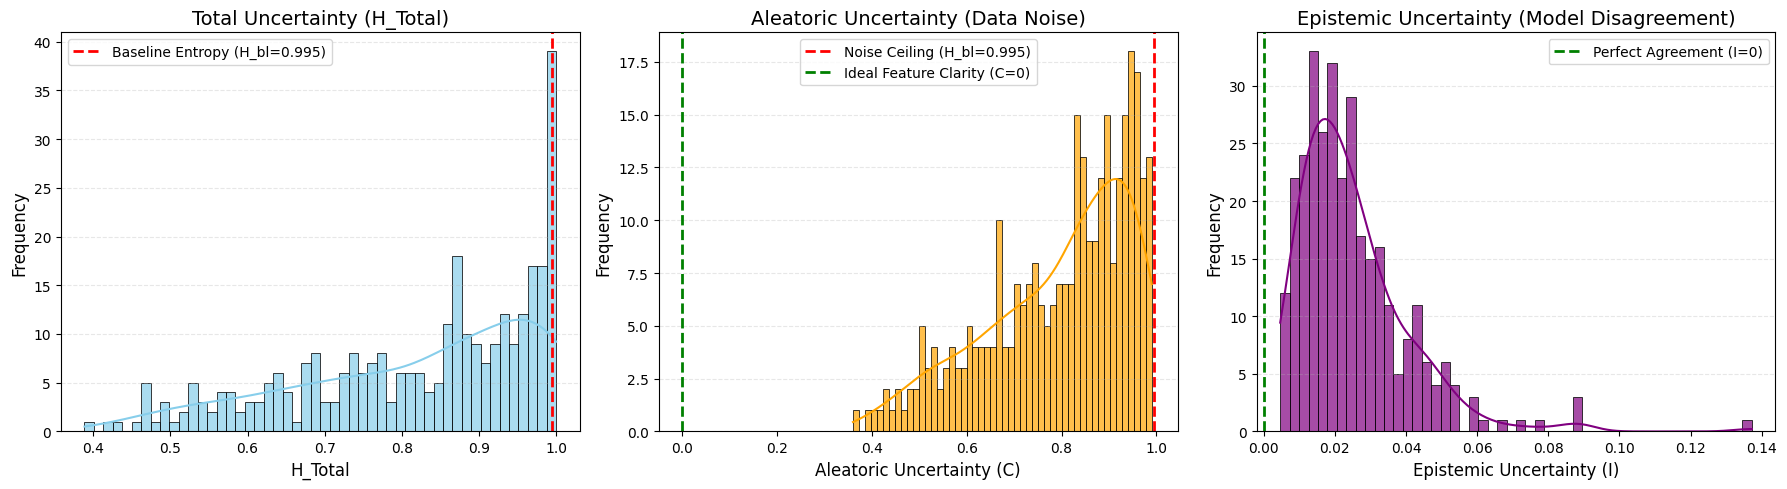

In [7]:
# Compute uncertainties for the non-active patients at baseline


uncertainty_results = compute_uncertainties(probs_raw_df)

# Create an explicit copy to avoid SettingWithCopyWarning
patients_stats_copy = patients_stats.copy()

# 2. Add the results to your main stats table
patients_stats_copy['H_Total'] = uncertainty_results['H_Total']
patients_stats_copy['C_Aleatoric'] = uncertainty_results['C_Aleatoric']
patients_stats_copy['I_Epistemic'] = uncertainty_results['I_Epistemic']


# Compute the baseline risk (mean of probs_cal across all folds) for each patient and its uncertainty value 
proportion_positive = all_patients['label'].sum() / len(all_patients)
H_bl = -(proportion_positive * np.log2(proportion_positive + 1e-12) +
         (1 - proportion_positive) * np.log2(1 - proportion_positive + 1e-12))
print("Baseline entropy:", H_bl)



plot_uncertainty_distributions(
     patients_stats_copy, 
     H_bl, 
     #save_path='../results/uncertainty/plots/uncertainty_distributions.png'
 )

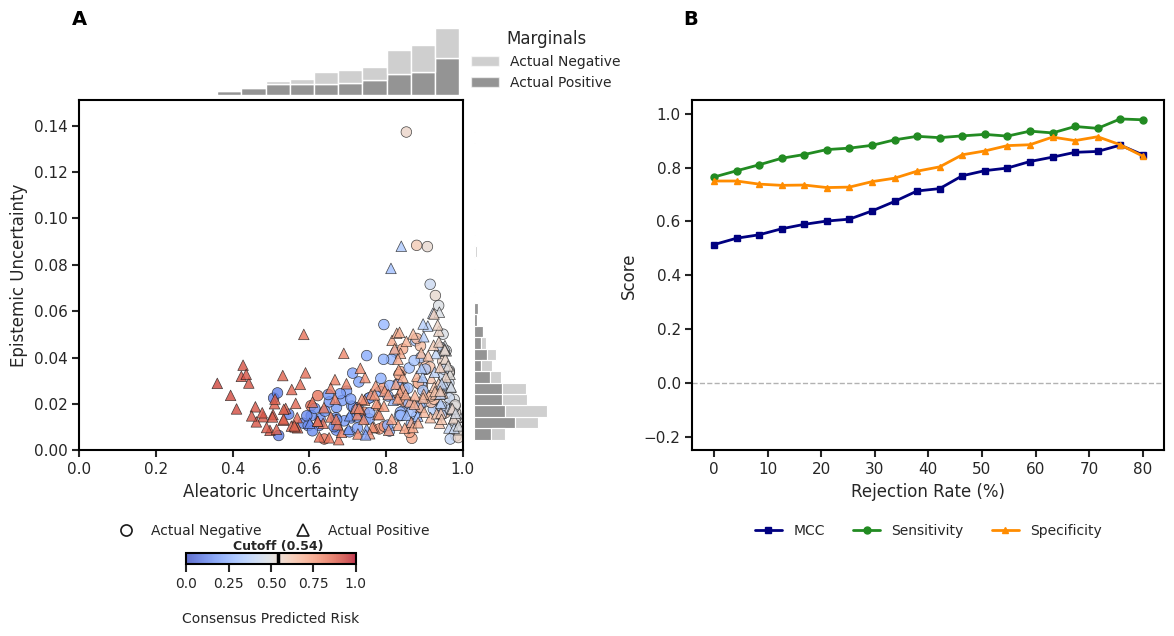

In [8]:
plot_combined_uncertainty_analysis(patients_stats_copy, uncertainty_type='C_Aleatoric', y_true=all_patients['label'])

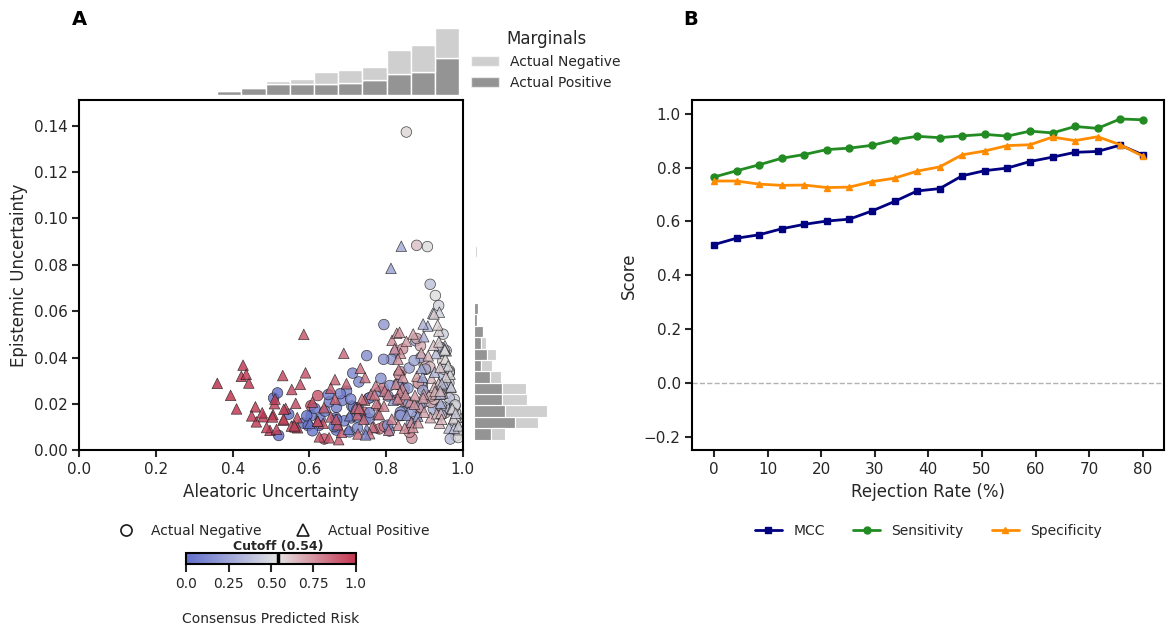

In [10]:
from lib.plots import plot_combined_uncertainty_analysis_v2


plot_combined_uncertainty_analysis_v2(patients_stats_copy, uncertainty_type='C_Aleatoric', y_true=all_patients['label'])

## Explore clinical data through GMM analysis
No clear separation between patients. The two scores do not agree on the number of clusters. For this dataset we are going to skip the GMM analysis and rejection and move on to Conditioned Classification Rejection Curves (CCRC).

Number of original clinical features: 11
Optimal PCs according to the Kaiser Rule: 4

Top 5 Eigenvalues:
[2.33 1.48 1.2  1.1  0.96]


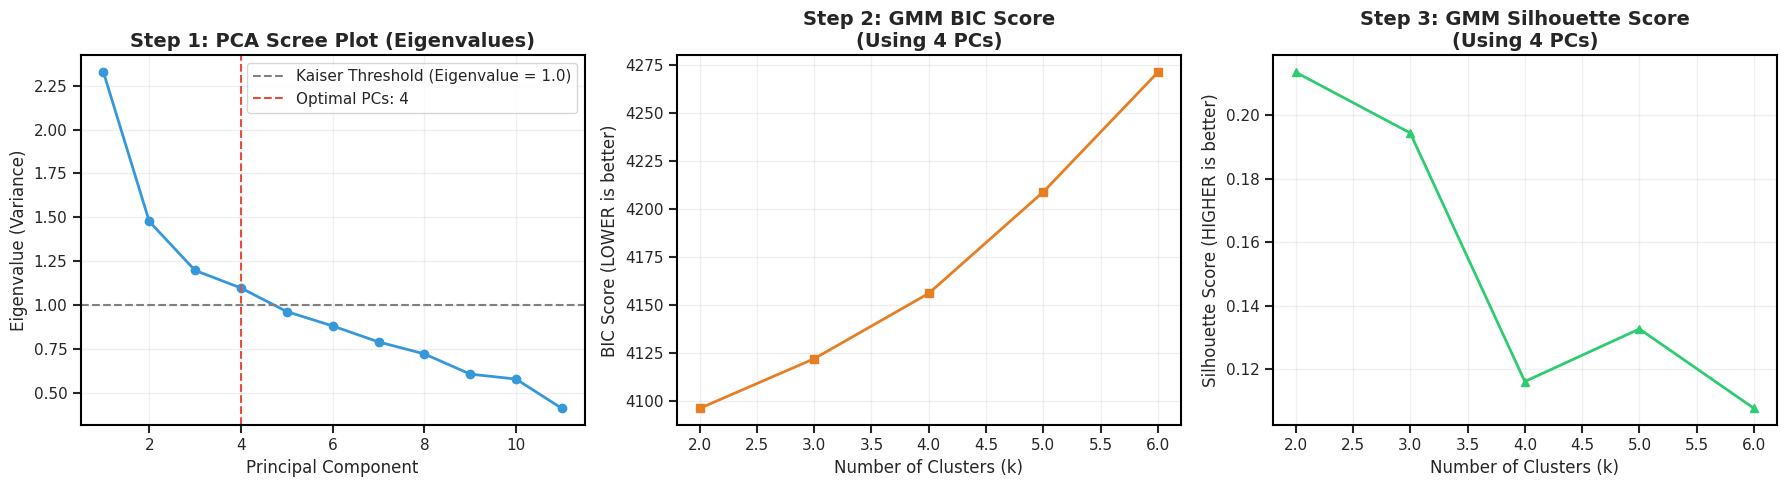


--- Optimization Results ---
1. Optimal PCs retained (Kaiser Rule, Eigenvalue > 1.0): 4
2. Best GMM model according to BIC (lowest complexity penalty): k = 2
3. Best GMM model according to Silhouette (highest separation): k = 2


In [11]:
from lib.clustering import optimize_pca_and_gmm_kaiser


optimize_pca_and_gmm_kaiser(X_clinical = all_patients.drop(['label'], axis=1), max_clusters=6)

## Conditioned Classification Rejection Curves (CCRC)

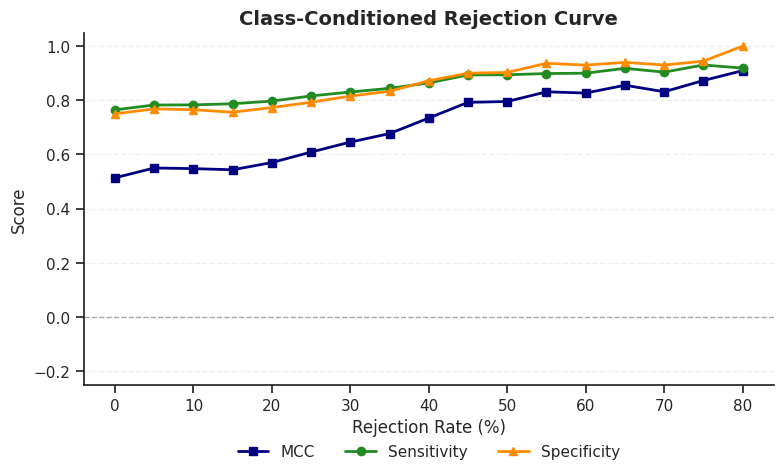

GLOBAL CLASS-CONDITIONED REJECTION: METRICS EVOLUTION
 Rejection (%)  Total Kept  TP  FP  TN  FN   MCC  Sensitivity  Specificity
             0         314 130  36 108  40 0.514        0.765        0.750
             5         299 126  32 106  35 0.550        0.783        0.768
            10         284 119  31 101  33 0.548        0.783        0.765
            15         268 111  31  96  30 0.543        0.787        0.756
            20         252 106  27  92  27 0.570        0.797        0.773
            25         236 102  23  88  23 0.609        0.816        0.793
            30         221  98  19  84  20 0.646        0.831        0.816
            35         205  92  16  80  17 0.677        0.844        0.833
            40         189  89  11  75  14 0.734        0.864        0.872
            45         174  84   8  72  10 0.792        0.894        0.900
            50         157  76   7  65   9 0.795        0.894        0.903
            55         142  71   4  59   8 0.8

In [12]:
from lib.plots import plot_class_conditioned_rejection_curve


optimal_threshold = all_patients['label'].mean()

class_cond_results = plot_class_conditioned_rejection_curve(
    patients_stats_copy, 
    threshold=optimal_threshold, 
    uncertainty_col='C_Aleatoric',
    rates=np.linspace(0, 80, 17)
)

### Confusion matrix evolution analysis


Standard global rejection frameworks fail in clinical datasets because predicting the onset of a future disease (Class 1) is inherently noisier than diagnosing baseline stability (Class 0). This Asymmetric Aleatoric Uncertainty causes standard algorithms to disproportionately delete the positive class, crashing the Sensitivity to zero.

By implementing Class-Conditioned Rejection tied to the baseline prior, we successfully decoupled the rejection threshold from this asymmetric noise.

Dataset 1 (The Imbalanced Cohort | Prior ~0.11) -> The "Rescue" Mechanism

Observation: The baseline model struggles with the rare minority class (Sens: ~0.69, MCC: 0.27).

Impact: Class-Conditioned Rejection actively rescues the model. By dropping the top 25% of uncertain patients proportionally from both predicted classes, Sensitivity actually rises to ~0.76 and holds steady. We successfully deferred a quarter of the most ambiguous patients without artificially collapsing the rare disease class.

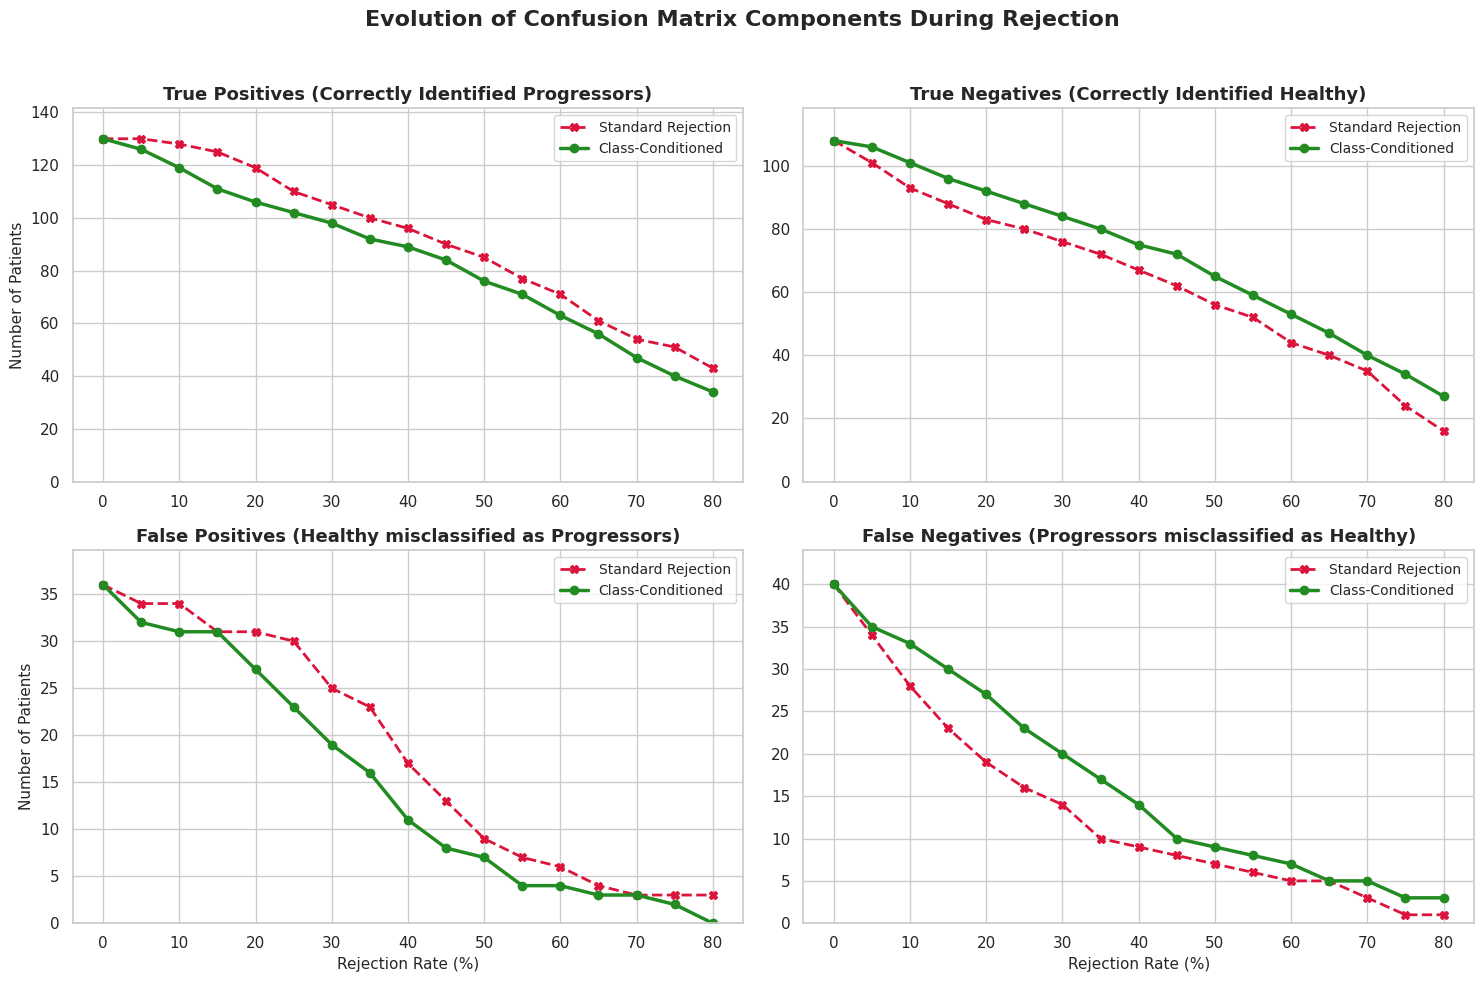

In [13]:
from lib.plots import plot_comprehensive_rejection_dashboard


optimal_threshold = patients_stats_copy['label'].mean()
dashboard_results = plot_comprehensive_rejection_dashboard(patients_stats_copy, uncertainty_col='C_Aleatoric', threshold=optimal_threshold)

In [14]:

from lib.utils import extract_and_analyze_rejection


optimal_threshold = patients_stats_copy['label'].mean()

# Extract the patients at a 25% rejection rate
kept_df, removed_df, uncertainty_stats = extract_and_analyze_rejection(
     patients_stats_copy, 
     prior_threshold=optimal_threshold, 
     rate=25, 
     method='class_conditioned',
     sort_col='C_Aleatoric',
     uncertainty_cols=['H_Total', 'C_Aleatoric', 'I_Epistemic', 'sigma']
)

REJECTION AUDIT: CLASS_CONDITIONED @ 25%
Total Cohort:    314 patients
Total Kept:      236 patients
Total Removed:   78 patients
--------------------------------------------------------------------------------
UNCERTAINTY PROFILE COMPARISON:
     Metric  Kept_Profile Removed_Profile P_Value
    H_Total 0.770 ± 0.146   0.976 ± 0.024  <0.001
C_Aleatoric 0.745 ± 0.139   0.950 ± 0.026  <0.001
I_Epistemic 0.025 ± 0.017   0.026 ± 0.012   0.023
      sigma 0.077 ± 0.030   0.092 ± 0.023  <0.001


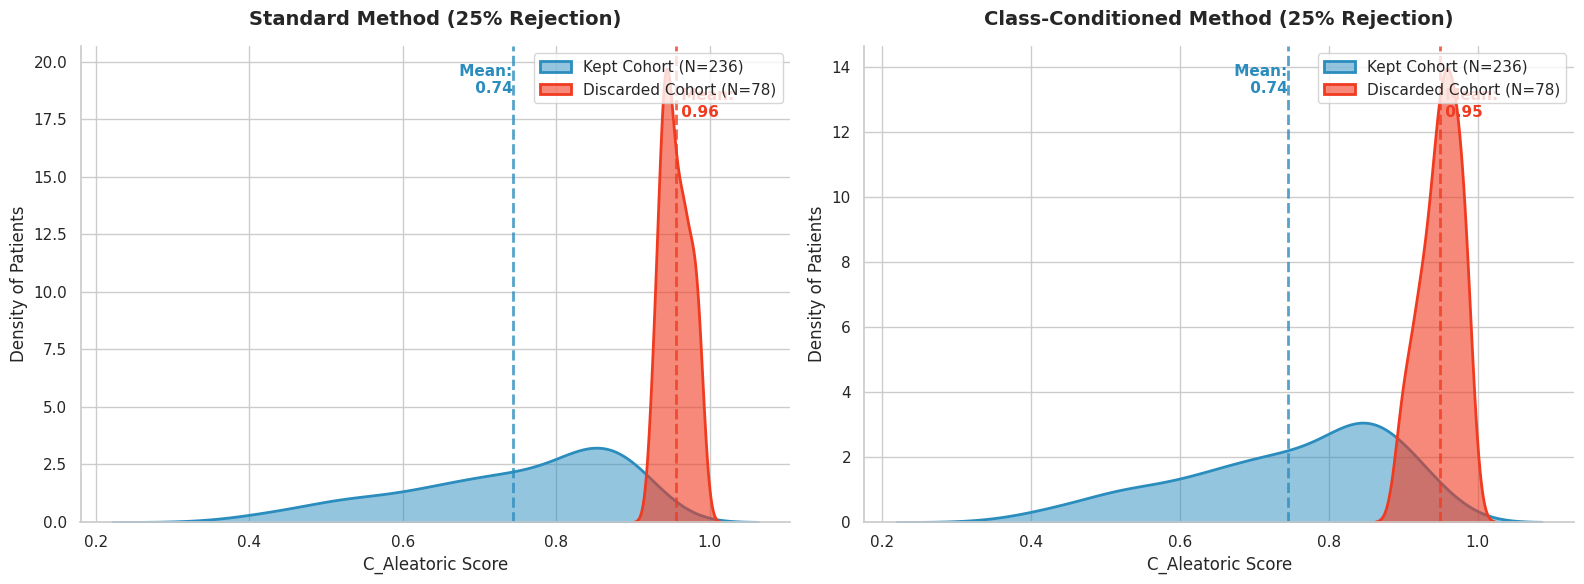

In [15]:


from lib.plots import plot_side_by_side_distributions


# --- Example Usage ---
optimal_threshold = patients_stats_copy['label'].mean()
plot_side_by_side_distributions(patients_stats_copy, uncertainty_col='C_Aleatoric', threshold=optimal_threshold, rate=25)